This notebook tests basic simulation by recapitulating a simulated dataset several times and measuring variance.

Imports

In [1]:
import sys
import os
import scMPRAforge as scm
import pandas as pd
import numpy as np

2025-08-11 17:09:35.980669: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-11 17:09:35.984619: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-08-11 17:09:35.984631: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

cluster=SLURMCluster(
    cores=4,#cores per slurm job
    memory="16G",#memory per slurm job
    processes=16,#dask workers
    job_extra_directives=["-p ycga", 
        f"--job-name=simclust_worker",
        f"--time=4:00:00",
        f"--output=slave_%j.out"]
)

cluster.scale(jobs=4)

client = Client(cluster,
        timeout=f"{5*60}s",   # Client <-> scheduler timeout 
        heartbeat_interval="20s"  # Worker heartbeat interval
    )

2025-08-11 19:46:28,838 - distributed.scheduler - ERROR - Task _smart_matrix-9c9f11b7385c47ecd31587a7cd422453 marked as failed because 4 workers died while trying to run it
2025-08-11 19:46:28,850 - distributed.scheduler - ERROR - Task _smart_matrix-7c06ba7a6aad3ed2ea41662ee233eb25 marked as failed because 4 workers died while trying to run it
2025-08-11 19:46:28,855 - distributed.scheduler - ERROR - Task _smart_matrix-b434c6fa72c00ba7bfb04530f0f68030 marked as failed because 4 workers died while trying to run it


Make the dask cluster & client in accordance with resource avail and model size

In [4]:
dat=scm.scMPRA_data.from_tsv("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres_v3.tsv")
dat.ortho_filter()
dat.set_negative_controls(["nobody","weak"])
dat.set_reference_cell("liver")

scMPRAforge: INFO: Dropped 0 of 27 (cell_type, cre_id) combos with fewer than 3 nonzero entries.


In [37]:
#let's make an ortho object out of the data on disc, we'll call 'primordial'
primordial=scm.ortho()
primordial.criss_cross(client=client,dat=dat)
primordial.extract_params(client)

In [38]:
batch=scm.simulation_batch(primordial)
batch.describe_primordial()

In [39]:
batch.simulate_many(client,3)

In [41]:
batch.fit_to_simulations(client)

In [73]:
batch.save(path="/gpfs/gibbs/pi/reilly/tabula_data/simulated",
           name="test_save_batch")

In [78]:
loaded=scm.simulation_batch.load(client,
                                 "/gpfs/gibbs/pi/reilly/tabula_data/simulated",
                                 "test_save_batch")

In [80]:
batch._nbs["id"].unique()

array(['primordial cre_id', 'primordial cell_type', 'cre_id->cre_id',
       'cre_id->cell_type', 'cell_type->cre_id', 'cell_type->cell_type'],
      dtype=object)

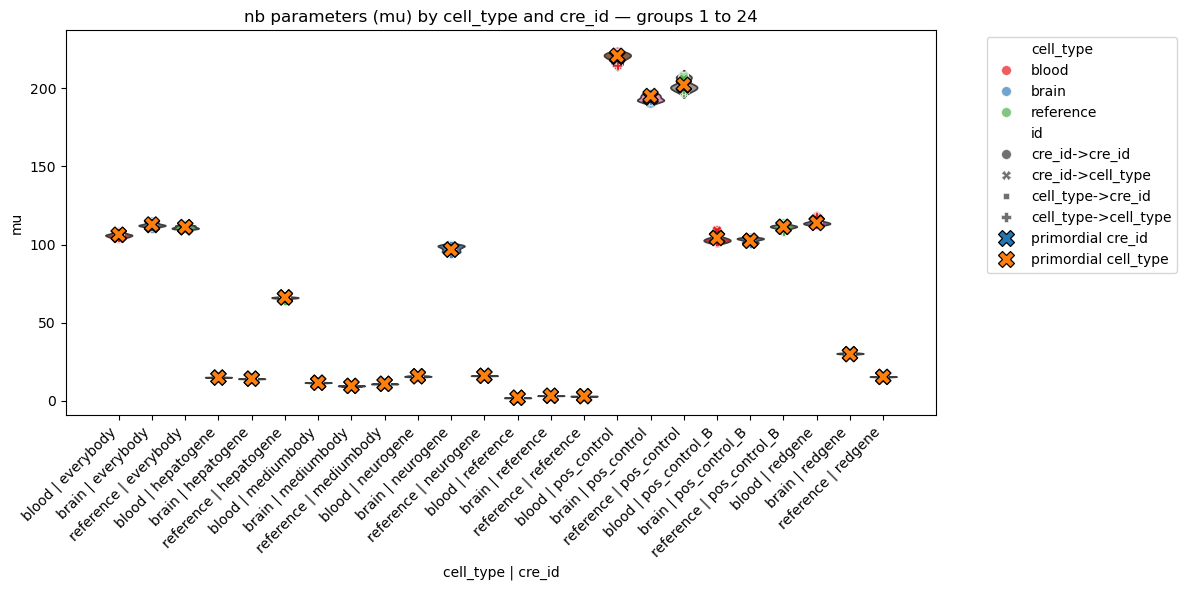

In [81]:
batch.plot_nb_spread()

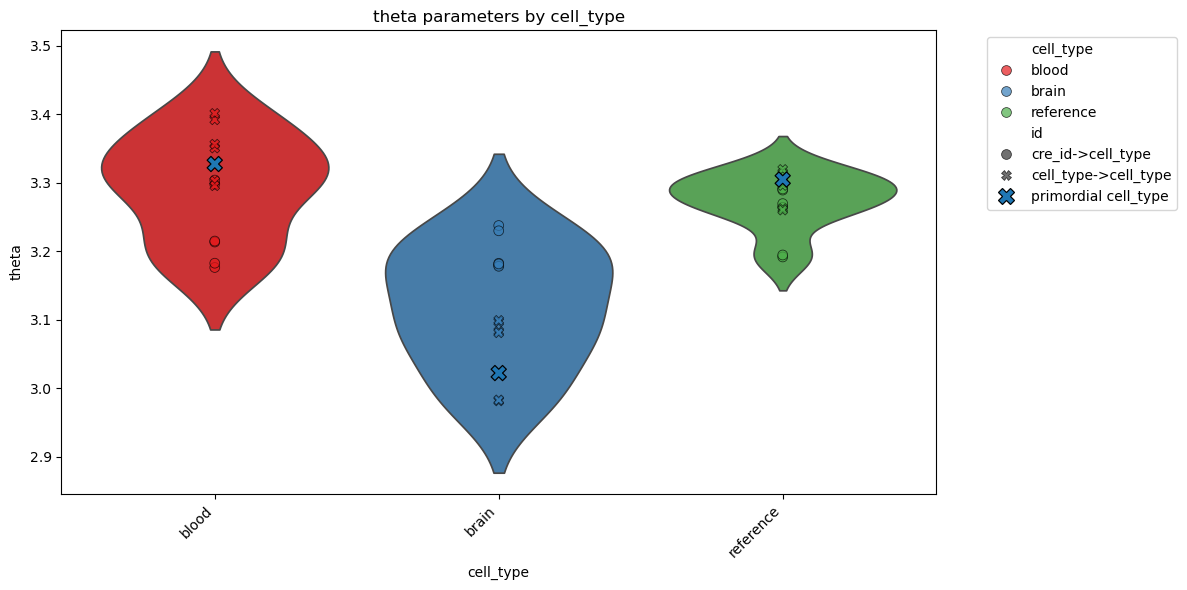

In [82]:
batch.plot_theta_spread("cell_type")

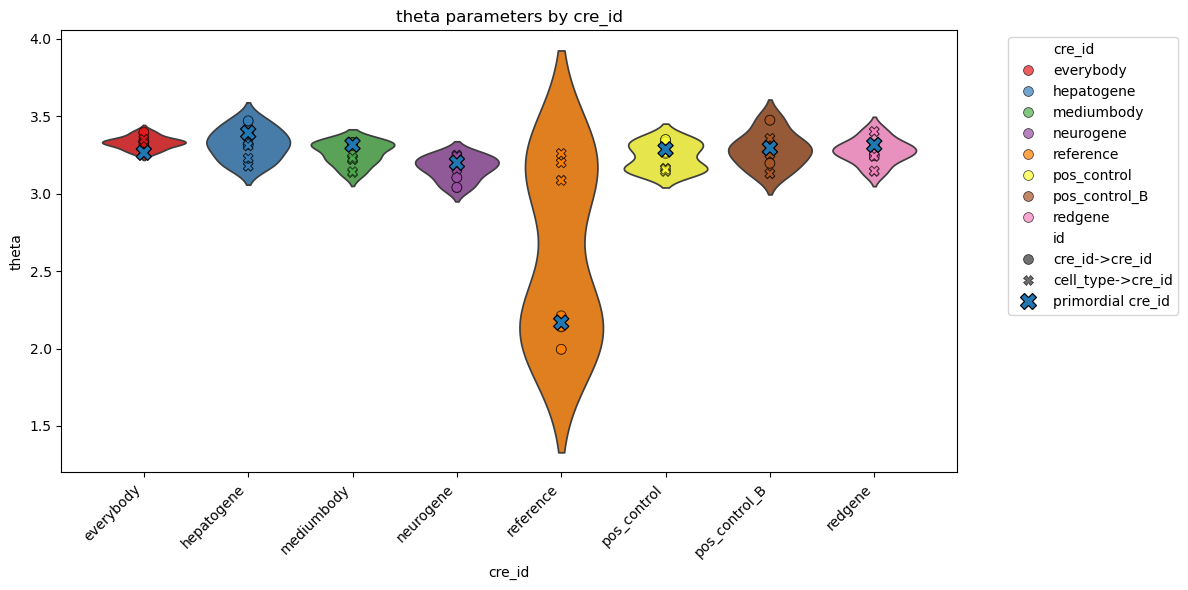

In [83]:
batch.plot_theta_spread("cre_id")

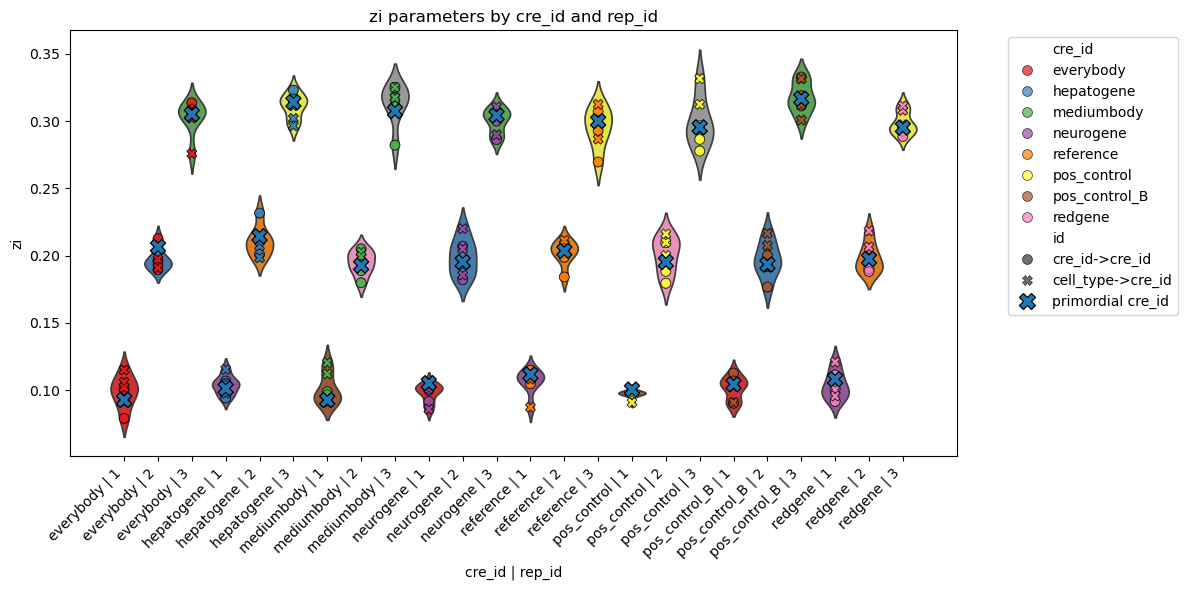

In [84]:
batch.plot_zi_spread("cre_id")

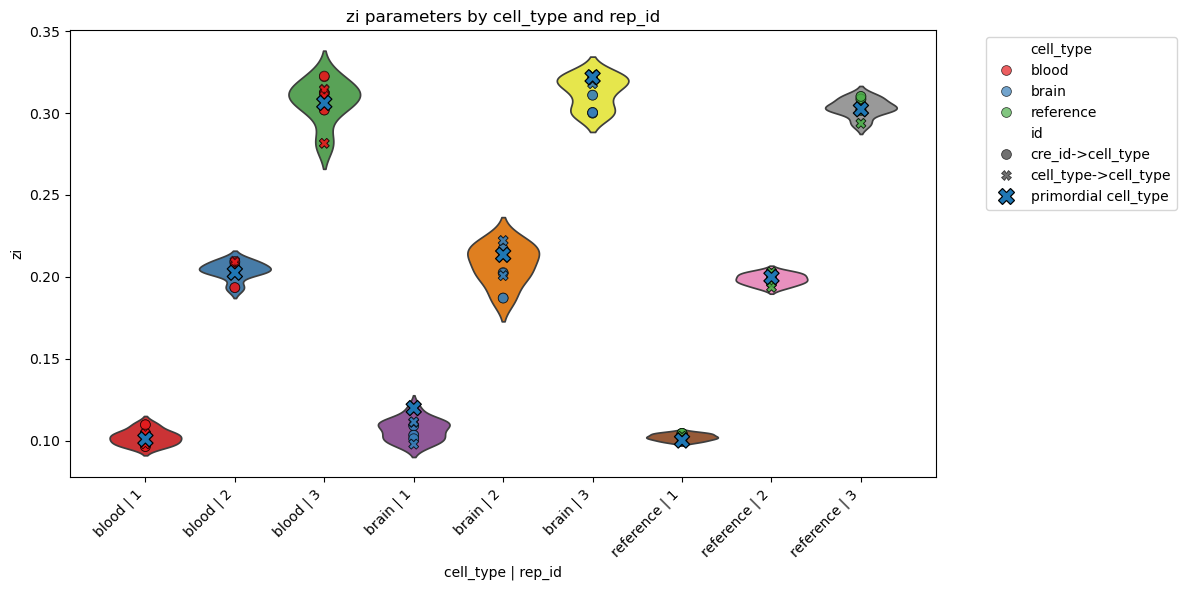

In [85]:
batch.plot_zi_spread("cell_type")

In [86]:
cluster.close()